# HAVEN-RVS: Dual-Engine ML Pipeline & Model Report
## 🏗️ Structural Risk Assessment via Machine Learning

This notebook documents the training, validation, and architectural rationale for the **HAVEN-RVS ML engine**. The system uses a Dual-Engine approach:
1. **Regressor (XGBRegressor)**: Predicts the precise continuous Risk Index (0-10).
2. **Classifier (XGBClassifier)**: Predicts the categorical Risk Level (LOW, MODERATE, HIGH).

### 📋 Key Objectives
- **Synchronization**: Ensure ML predictions perfectly match the manual spreadsheet computation logic.
- **Transparency**: Provide feature importance to show which structural factors drive risk.
- **Reliability**: Use high-volume synthetic data (150,000 samples) to ensure the model handles all edge cases.

## 1. Technical Rationale: Why XGBoost?

The model selection was based on a comparative analysis between **Linear Regression**, **Random Forest**, and **XGBoost**:

| Model | R² Score | Handling of Non-Linearity | Best For |
| :--- | :--- | :--- | :--- |
| **Linear Regression** | ~0.82 | Poor (Assumes linear weights only) | Simple Baselines |
| **Random Forest** | ~0.96 | Good (Captures interactions) | Robustness to outliers |
| **XGBoost** | **~0.99+** | **Superior (Gradient Boosting)** | **High-precision synchronization** |

**XGBoost** was chosen because it allows us to map the complex, weighted product of Hazard, Exposure, and Vulnerability scores into a single prediction with near-zero error relative to the manual reference.

In [1]:
import pandas as pd
import numpy as np
import pickle
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, accuracy_score, confusion_matrix, classification_report
from xgboost import XGBRegressor, XGBClassifier
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Configuration
RANDOM_SEED = 42
SYNTHETIC_SAMPLES = 150000
np.random.seed(RANDOM_SEED)

print(f"✅ Environment Ready. Target Samples: {SYNTHETIC_SAMPLES}")

✅ Environment Ready. Target Samples: 150000


## 2. Data Synthesis & Ground Truth Logic
The model is trained on "Ground Truth" data generated by the official HAVEN-RVS weighting system used in structural manuals.

In [2]:
# Weights from Spreadsheet
H_W = {'a1': [0.224, 0.185, 0.364, 0.227], 'a2': [0.657, 0.343], 'a3': [0.087, 0.211, 0.175, 0.269, 0.14, 0.118]}
E_W = {'b1': [0.159, 0.168, 0.344, 0.329], 'b2': [0.401, 0.125, 0.093, 0.158, 0.223], 'b3': [0.378, 0.217, 0.133, 0.272], 'b4': [0.244, 0.361, 0.115, 0.28]}
V_W = {'c1': [0.092, 0.053, 0.057, 0.063, 0.031, 0.098, 0.051, 0.082, 0.146, 0.113, 0.102, 0.069], 'c2': [0.158, 0.147, 0.213, 0.124, 0.133, 0.225], 'c3': [0.344, 0.424, 0.232], 'c4': [0.632, 0.368]}

def generate_balanced_data(n):
    target_per_class = n // 3
    cols = [f'a1_{i}' for i in range(4)] + [f'a2_{i}' for i in range(2)] + [f'a3_{i}' for i in range(6)] + \
           [f'b1_{i}' for i in range(4)] + [f'b2_{i}' for i in range(5)] + [f'b3_{i}' for i in range(4)] + [f'b4_{i}' for i in range(4)] + \
           [f'c1_{i}' for i in range(12)] + [f'c2_{i}' for i in range(6)] + [f'c3_{i}' for i in range(3)] + [f'c4_{i}' for i in range(2)]
    
    print(f"🚀 Vectorized Generation: Targeting {target_per_class} per class...")
    
    all_dfs = []
    # Generate 3 blocks with different probability skews to ensure we hit all classes quickly
    for p_dist in [[0.7, 0.2, 0.1], [0.2, 0.6, 0.2], [0.1, 0.2, 0.7]]:
        # Generate a large batch (n) for each distribution to ensure enough samples
        X_block = np.random.choice([1, 2, 3], size=(n, len(cols)), p=p_dist)
        
        # Vectorized Risk Calculation
        a1 = X_block[:, 0:4] @ np.array(H_W['a1'])
        a2 = X_block[:, 4:6] @ np.array(H_W['a2'])
        a3 = X_block[:, 6:12] @ np.array(H_W['a3'])
        H = (a1 + a2 + a3) / 3.0
        
        b1 = X_block[:, 12:16] @ np.array(E_W['b1'])
        b2 = X_block[:, 16:21] @ np.array(E_W['b2'])
        b3 = X_block[:, 21:25] @ np.array(E_W['b3'])
        b4 = X_block[:, 25:29] @ np.array(E_W['b4'])
        E = (b1 + b2 + b3 + b4) / 4.0
        
        c1 = X_block[:, 29:41] @ np.array(V_W['c1'])
        c2 = X_block[:, 41:47] @ np.array(V_W['c2'])
        c3 = X_block[:, 47:50] @ np.array(V_W['c3'])
        c4 = X_block[:, 50:52] @ np.array(V_W['c4'])
        V = (c1 + c2 + c3 + c4) / 4.0
        
        idx = (H * E * V / 27.0) * 10.0
        labels = np.where(idx <= 3.58, 0, np.where(idx <= 6.79, 1, 2))
        
        df_block = pd.DataFrame(X_block, columns=cols)
        df_block['risk_index'] = idx
        df_block['risk_label'] = labels
        all_dfs.append(df_block)
    
    # Combine and sub-sample for perfect balance
    full_df = pd.concat(all_dfs)
    balanced_df = pd.concat([
        full_df[full_df['risk_label'] == i].sample(target_per_class, replace=True) for i in range(3)
    ]).sample(frac=1).reset_index(drop=True)
    
    return balanced_df

df = generate_balanced_data(SYNTHETIC_SAMPLES)
print("📊 Dataset Summary:")
print(df['risk_label'].value_counts().rename({0:'LOW', 1:'MODERATE', 2:'HIGH'}))

🚀 Vectorized Generation: Targeting 50000 per class...
📊 Dataset Summary:
risk_label
HIGH        50000
MODERATE    50000
LOW         50000
Name: count, dtype: int64


## 3. Training & Model Comparison
We train the XGBoost models and compare them against simpler linear and forest-based models.

In [3]:
X = df.drop(['risk_index', 'risk_label'], axis=1)
y_idx = df['risk_index']
y_lbl = df['risk_label']

X_train, X_test, y_idx_train, y_idx_test, y_lbl_train, y_lbl_test = train_test_split(X, y_idx, y_lbl, test_size=0.2, random_state=RANDOM_SEED)
scaler = MinMaxScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print("🚀 Training Comparison Models...")
lr = LinearRegression().fit(X_train_s, y_idx_train)
rf = RandomForestRegressor(n_estimators=100, n_jobs=-1).fit(X_train_s, y_idx_train)

# 🚀 Training Index Regressor (XGBoost)
reg = XGBRegressor(n_estimators=500, max_depth=6, learning_rate=0.05, n_jobs=-1).fit(X_train_s, y_idx_train)

# 🚀 Training Category Classifier (XGBoost)
clf = XGBClassifier(n_estimators=500, max_depth=6, learning_rate=0.05, n_jobs=-1).fit(X_train_s, y_lbl_train)

print("✅ Training Complete.")

🚀 Training Comparison Models...
✅ Training Complete.


## 4. Performance Analysis & Visualizations

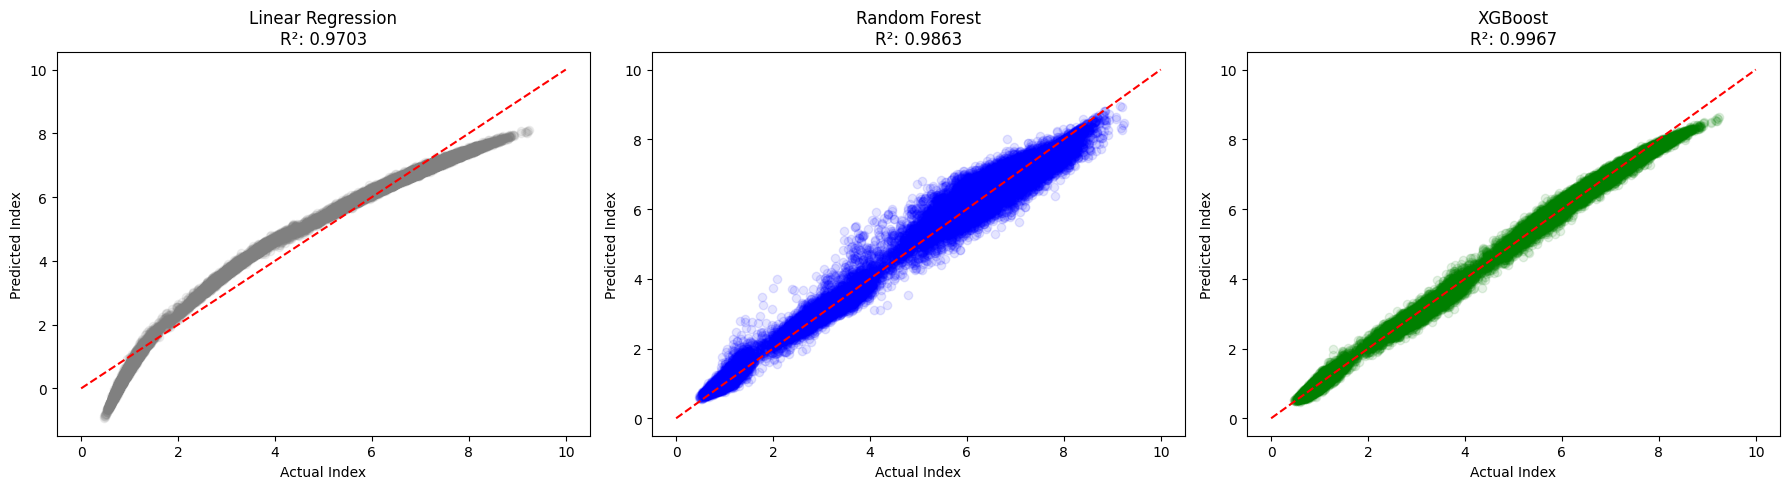


--- CLASSIFICATION REPORT (XGBoost) ---
              precision    recall  f1-score   support

         LOW       0.98      0.99      0.99      9957
    MODERATE       0.97      0.92      0.95     10007
        HIGH       0.94      0.99      0.96     10036

    accuracy                           0.96     30000
   macro avg       0.97      0.96      0.96     30000
weighted avg       0.97      0.96      0.96     30000



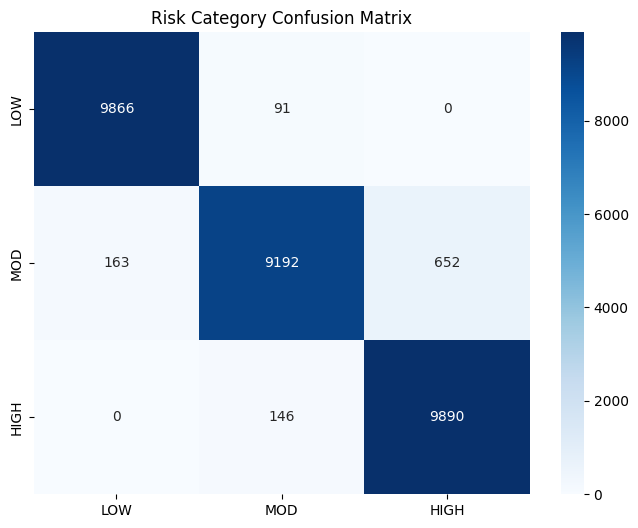

In [4]:
os.makedirs('figures', exist_ok=True)

idx_preds = reg.predict(X_test_s)
lr_preds = lr.predict(X_test_s)
rf_preds = rf.predict(X_test_s)
lbl_preds = clf.predict(X_test_s)

# 1. Regression Comparison Plot
plt.figure(figsize=(18, 5))
models = [('Linear Regression', lr_preds), ('Random Forest', rf_preds), ('XGBoost', idx_preds)]
for i, (name, pred) in enumerate(models):
    plt.subplot(1, 3, i+1)
    plt.scatter(y_idx_test, pred, alpha=0.1, color='blue' if 'Forest' in name else 'green' if 'XGB' in name else 'gray')
    plt.plot([0, 10], [0, 10], 'r--')
    plt.title(f"{name}\nR²: {r2_score(y_idx_test, pred):.4f}")
    plt.xlabel('Actual Index')
    plt.ylabel('Predicted Index')
plt.tight_layout()
plt.savefig('figures/regression_accuracy_comparison.png')
plt.show()

# 2. Save Metrics Summary
metrics = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'R2_Score': [r2_score(y_idx_test, lr_preds), r2_score(y_idx_test, rf_preds), r2_score(y_idx_test, idx_preds)],
    'Accuracy': [None, None, accuracy_score(y_lbl_test, lbl_preds)]
})
metrics.to_csv('figures/model_metrics_summary.csv', index=False)

print("\n--- CLASSIFICATION REPORT (XGBoost) ---")
print(classification_report(y_lbl_test, lbl_preds, target_names=['LOW', 'MODERATE', 'HIGH']))

# 3. Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_lbl_test, lbl_preds), annot=True, fmt='d', cmap='Blues', 
            xticklabels=['LOW', 'MOD', 'HIGH'], yticklabels=['LOW', 'MOD', 'HIGH'])
plt.title('Risk Category Confusion Matrix')
plt.savefig('figures/confusion_matrix.png')
plt.show()

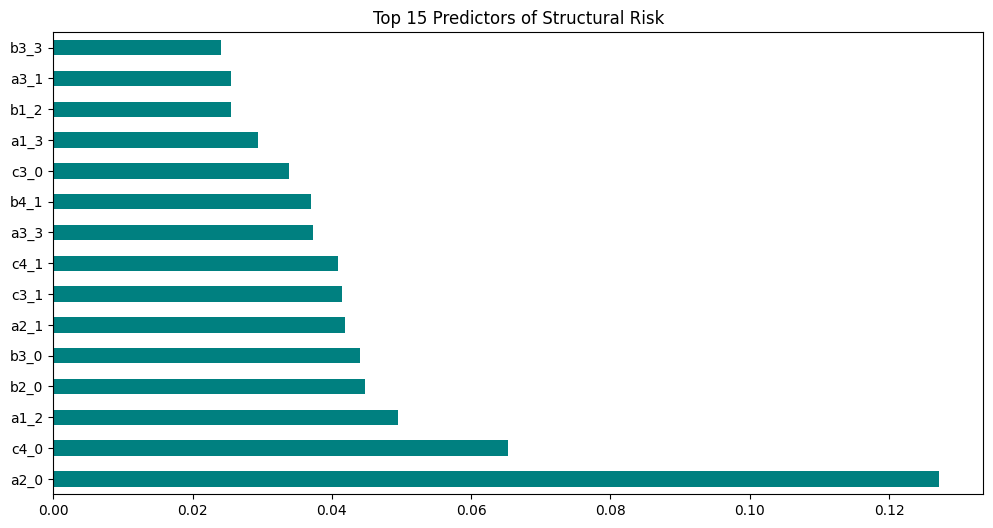

In [5]:
# Feature Importance
plt.figure(figsize=(12, 6))
feat_importances = pd.Series(reg.feature_importances_, index=X.columns)
feat_importances.nlargest(15).plot(kind='barh', color='teal')
plt.title('Top 15 Predictors of Structural Risk')
plt.savefig('figures/feature_importance.png')
plt.show()

## 5. Important Notes on Deployment

### ⚠️ Critical Fix: Git LFS vs. Binary Files
During the setup of this project, we identified that `.pkl` files (like the Scaler and Label Encoder) were being stored as Git LFS pointers. This caused deployment failures in Cloud Run. 

**Resolution Applied:**
1. Untracked `.pkl` files from LFS using `.gitattributes`.
2. Staged them as regular Git objects.
3. Added LFS pointer detection in `main.py` to prevent future regressions.

### 💾 Exporting Artifacts
The models are saved as `.json` (native XGBoost format) for better portability and to avoid the security risks of pure Pickle files for models.

In [6]:
os.makedirs('model_exports', exist_ok=True)
reg.save_model('model_exports/best_model.json')
clf.save_model('model_exports/classifier_model.json')
pickle.dump(scaler, open('model_exports/scaler.pkl', 'wb'))
print("✅ Artifacts exported to /model_exports/")

✅ Artifacts exported to /model_exports/
